In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

import os

2026-03-13 15:18:52.368945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Question 1

## 1. Preprocessing

#### Load the data folder

In [126]:
inside_paths  = [os.path.join("fence_renamed/inside",  f) for f in os.listdir("fence_renamed/inside")  if f.endswith(".jpg")]
outside_paths = [os.path.join("fence_renamed/outside", f) for f in os.listdir("fence_renamed/outside") if f.endswith(".jpg")]

# Shuffle the data
np.random.shuffle(inside_paths)
np.random.shuffle(outside_paths)

#### Balance the binary dataset
Done to reduce classification bias

In [127]:
n_samples = min(len(inside_paths), len(outside_paths))
inside_paths = inside_paths[:n_samples]
outside_paths = outside_paths[:n_samples]
print(f"Balanced: {n_samples} per class, {n_samples * 2} total")

Balanced: 145 per class, 290 total


#### Load the actual images
Done using CV2. The images are then converted to grayscale and then thresholed to binary (0 and 1). The image is also resized to reduce the parameters for the model

In [128]:
IMG_SIZE = (128, 128)

images = []

for p in inside_paths + outside_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    _, img = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY_INV)
    images.append(img)

images = np.array(images, dtype="float32") / 255.0
images = images[..., np.newaxis]

labels = np.array([0] * len(inside_paths) + [1] * len(outside_paths), dtype="float32")

#### Split the data into training and testing sets

In [129]:
# shuffle
idx = np.random.permutation(len(images))
images, labels = images[idx], labels[idx]

# split
split = int(len(images) * 0.8)
train_data, test_data  = images[:split], images[split:]
train_labels, test_labels = labels[:split], labels[split:]

print(f"Total: {len(images)}\nTrain: {len(train_data)}, Test: {len(test_data)}")
print("-------------------")
print(f"Train = Inside: {int((train_labels==0).sum())} ; Outside: {int((train_labels==1).sum())}")
print(f"Test = Inside: {int((test_labels==0).sum())} ; Outside: {int((test_labels==1).sum())}")

Total: 290
Train: 232, Test: 58
-------------------
Train = Inside: 117 ; Outside: 115
Test = Inside: 28 ; Outside: 30


### Visualize the Images

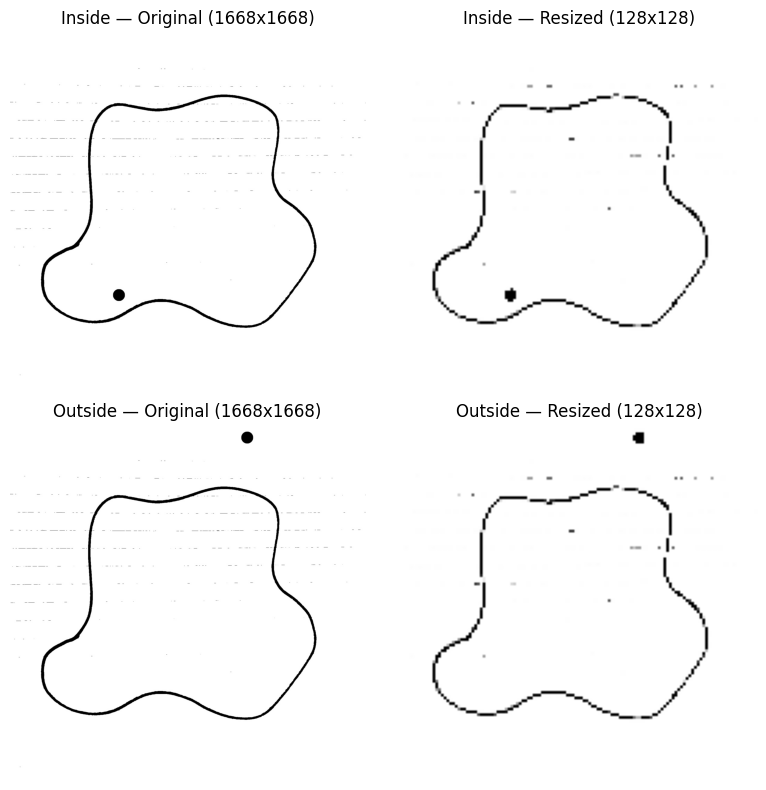

In [130]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for row, (path, label) in enumerate([(inside_paths[0], "Inside"), (outside_paths[0], "Outside")]):
    original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    resized  = cv2.cvtColor(cv2.resize(cv2.imread(path), IMG_SIZE), cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(original)
    axes[row][0].set_title(f"{label} — Original ({original.shape[1]}x{original.shape[0]})")
    axes[row][0].axis("off")

    axes[row][1].imshow(resized)
    axes[row][1].set_title(f"{label} — Resized ({IMG_SIZE[0]}x{IMG_SIZE[1]})")
    axes[row][1].axis("off")

plt.tight_layout()
plt.show()

## 2. Constructing the FCN

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128,128,1)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, epochs=100, validation_data=(test_data, test_labels))

test_loss, test_accuracy = model.evaluate(test_data, test_labels, verbose=2)
print(f'Test accuracy: {test_accuracy}')

train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.4784 - loss: 0.7006 - val_accuracy: 0.4828 - val_loss: 0.7065
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5388 - loss: 0.6827 - val_accuracy: 0.5172 - val_loss: 0.6876
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6164 - loss: 0.6693 - val_accuracy: 0.7069 - val_loss: 0.6836
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7241 - loss: 0.6490 - val_accuracy: 0.5345 - val_loss: 0.6775
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8448 - loss: 0.6246 - val_accuracy: 0.7759 - val_loss: 0.6699
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.5856 - val_accuracy: 0.7586 - val_loss: 0.6590
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.5421 - val_accuracy: 0.5517 - val_loss: 0.6580
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.4937 - val_accuracy: 0.7586 - val_loss

#### Visualize the Results

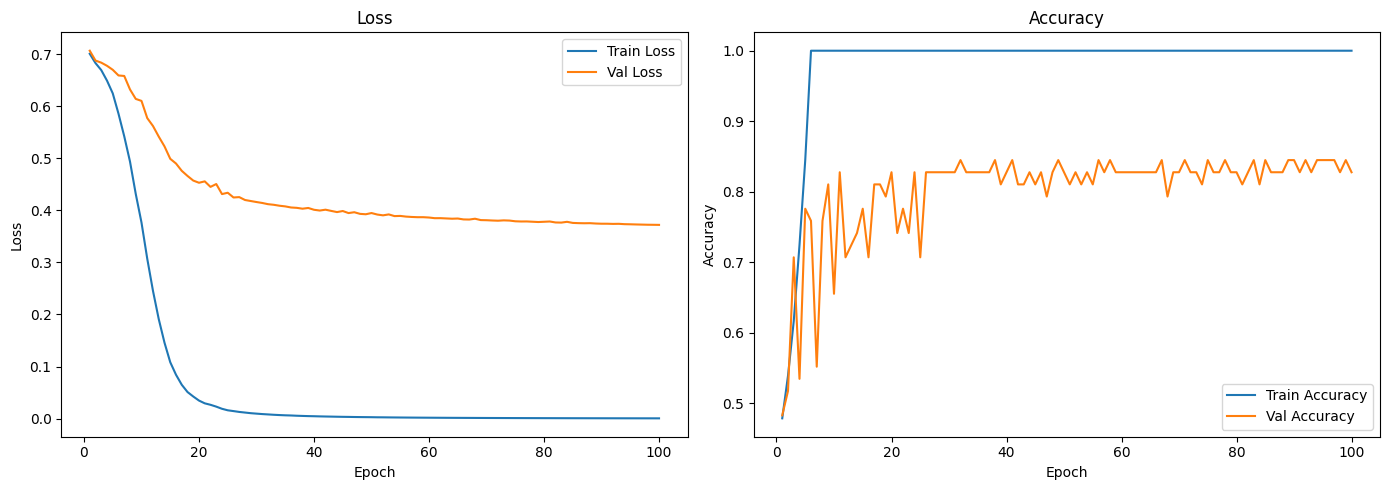

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs, history.history['loss'], label='Train Loss')
ax1.plot(epochs, history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history.history['accuracy'], label='Train Accuracy')
ax2.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

#### Confusion Matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
[[20  8]
 [ 2 28]]


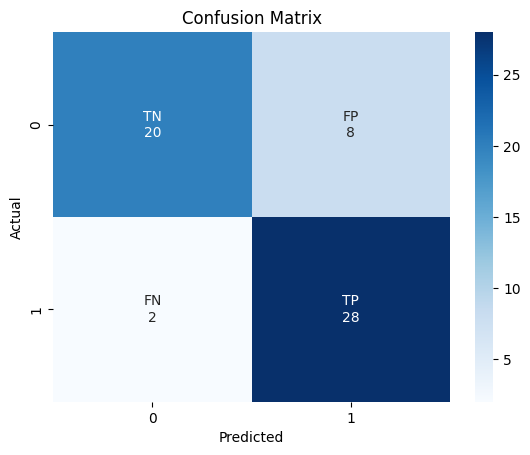

In [133]:

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(test_labels, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()

labels = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

##### Eval Scores

In [134]:
accuracy = accuracy_score(test_labels, y_pred)
precision = precision_score(test_labels, y_pred)
recall = recall_score(test_labels, y_pred)
f1 = f1_score(test_labels, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8276
Precision: 0.7778
Recall: 0.9333
F1 Score: 0.8485


### Conclusion
The model even though overfitting due to lack of data still learns as we see the training loss and the validation loss decreasing as epochs go on.

The oscillation behaviour in the validaiton accuracy occurs due to a smaller validation/test dataset as well. Each misclassification changes the accuracy significantly.

In the end we still acquire a good Accuracy given such a simple network and such less dataset

Note:
Cruicial things in getting high enough accuracy lies in converting the images to binary pixels and balancing out the dataset. plus shuffling given how we are importing the dataset (folder by folder)

---


# Question 2

In [13]:
from scipy.linalg import ishermitian

## 1. Generating Data

### Define validation functions

In [14]:
def is_valid(matrix):

    eigenvalues = np.linalg.eigvals(matrix)
    trace = np.trace(matrix)

    cond1 = ishermitian(matrix)
    cond2 = np.all(eigenvalues >= 0)
    cond3 = np.isclose(trace, 1)

    return cond1 and cond2 and cond3

def make_valid_matrix():
    A = np.random.randn(2,2)
    rho = A @ A.conj().T
    rho = rho / np.trace(rho)

    return rho

### Generate Data

In [ ]:
valid_matrices = []
invalid_matrices = []

for _ in range(5000):
    matrix = make_valid_matrix()
    valid_matrices.append(matrix)

done = False
while not done:
    matrix = np.random.randn(2,2)

    if not is_valid(matrix):
        invalid_matrices.append(matrix)

    if len(invalid_matrices) >= 5000:
        done = True

### Split the data for training and testing

In [16]:
X = np.concatenate([valid_matrices, invalid_matrices])
y = np.concatenate([np.ones(len(valid_matrices)),
                    np.zeros(len(invalid_matrices))])

idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


## 2. Training the Neural Net

In [19]:
model_matrix = models.Sequential([
    layers.Input(shape=(2,2)),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_matrix.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_matrix = model_matrix.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test)
)

test_loss, test_acc = model_matrix.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7699 - loss: 0.6082 - val_accuracy: 0.9235 - val_loss: 0.4990
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9345 - loss: 0.4179 - val_accuracy: 0.9385 - val_loss: 0.3621
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9433 - loss: 0.3251 - val_accuracy: 0.9530 - val_loss: 0.2944
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9554 - loss: 0.2661 - val_accuracy: 0.9620 - val_loss: 0.2406
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9712 - loss: 0.2127 - val_accuracy: 0.9810 - val_loss: 0.1896
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.1667 - val_accuracy: 0.9885 - val_loss: 0.1526
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9914 - loss: 0.1344 - val_accuracy: 0.9910 - val_loss: 0.1262
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.1120 - val_accuracy: 0.

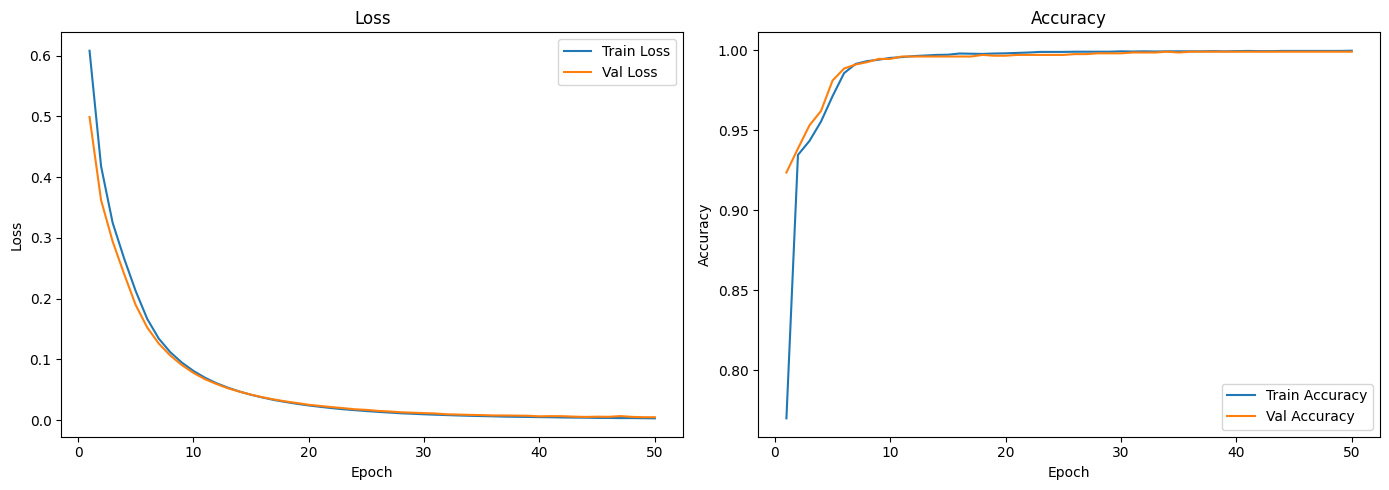

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_matrix.history['loss']) + 1)

ax1.plot(epochs, history_matrix.history['loss'], label='Train Loss')
ax1.plot(epochs, history_matrix.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history_matrix.history['accuracy'], label='Train Accuracy')
ax2.plot(epochs, history_matrix.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[ 972    2]
 [   0 1026]]


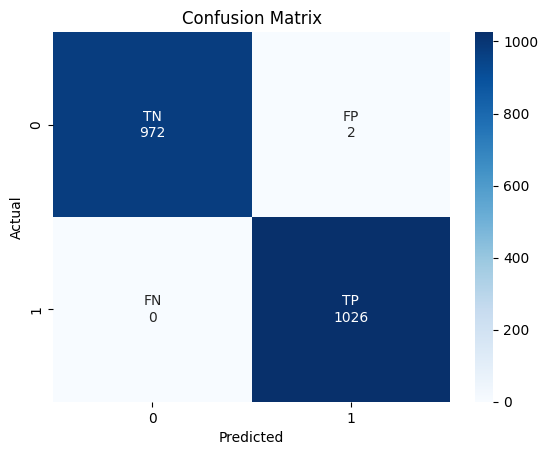

In [21]:
y_pred_matrix = model_matrix.predict(X_test)
y_pred_matrix = (y_pred_matrix > 0.5)

cm = confusion_matrix(y_test, y_pred_matrix)
print(cm)

tn, fp, fn, tp = cm.ravel()

labels = [
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
]

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
accuracy = accuracy_score(y_test, y_pred_matrix)
precision = precision_score(y_test, y_pred_matrix)
recall = recall_score(y_test, y_pred_matrix)
f1 = f1_score(y_test, y_pred_matrix)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9990
Precision: 0.9981
Recall: 1.0000
F1 Score: 0.9990


Even though the training is overfitting we still get 99% accuracy and good training and validation loss landscapes. This just shows how easy is the problem for FCN to solve